<a href="https://colab.research.google.com/github/antoniocesar-amf/ppcompann/blob/main/Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv -O beijing_pm25.csv

import os
from pprint import pprint

fname = os.path.join('beijing_pm25.csv')
with open(fname) as f:
  data = f.read()

lines = data.split('\n')
header = lines[0].split(',')
lines = [l.strip() for l in lines[1:] if l.strip()]

pprint(header)
print(len(lines))
print(f"{len(lines)/24} dias")
print(f"{len(lines)/(24*365)} anos")

--2026-07-07 01:46:49--  https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘beijing_pm25.csv’

beijing_pm25.csv        [    <=>             ]   1.92M  2.12MB/s    in 0.9s    

2026-07-07 01:46:51 (2.12 MB/s) - ‘beijing_pm25.csv’ saved [2010494]

['No',
 'year',
 'month',
 'day',
 'hour',
 'pm2.5',
 'DEWP',
 'TEMP',
 'PRES',
 'cbwd',
 'Iws',
 'Is',
 'Ir']
43824
1826.0 dias
5.002739726027397 anos


Base Beijing PM2.5, com dados horários de poluição e variáveis meteorológicas de 2010 a 2014.

In [10]:
for i, line in enumerate(lines):
  values = line.split(',')
  if len(values) != 13:
    print(i)
    print(values)
    break

In [11]:
import numpy as np

n_features = 7
raw_data = np.zeros((len(lines), n_features))
pm25 = np.zeros((len(lines),))

last_valid = 0.0
for i, line in enumerate(lines):
  values = line.split(',')
  if values[5] == 'NA':
    pm_val = last_valid
  else:
    pm_val = float(values[5])
    last_valid = pm_val
  pm25[i] = pm_val
  raw_data[i, :] = [pm_val, float(values[6]), float(values[7]),
                    float(values[8]), float(values[10]),
                    float(values[11]), float(values[12])]

print(raw_data.shape)

(43824, 7)


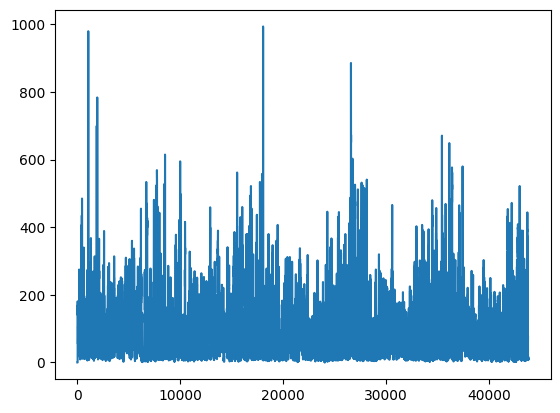

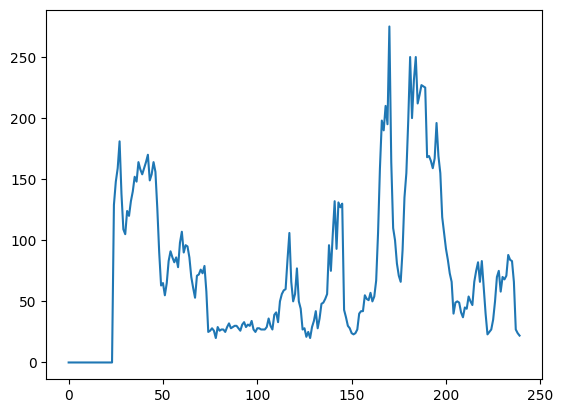

In [12]:
from matplotlib import pyplot as plt

plt.plot(range(len(pm25)), pm25)
plt.show()

ten_days = 24*10
plt.plot(range(ten_days), pm25[:ten_days])
plt.show()

In [13]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print('num_train_samples:', num_train_samples)
print('num_val_samples:', num_val_samples)
print('num_test_samples:', num_test_samples)

mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std
print(f"mean: {mean[0]}")
print(f"std: {std[0]}")

num_train_samples: 21912
num_val_samples: 10956
num_test_samples: 10956
mean: 98.7526013143483
std: 90.12534977232127


In [14]:
from tensorflow import keras

# parâmetros do dataset
# sampling_rate = 1 porque os dados já são horários
# sequence_length = 120 -> 5 dias de histórico
# delay = previsão de 24 horas à frente
sampling_rate = 1
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=pm25[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=pm25[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=pm25[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples
)

for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 7)
targets shape: (256,)


In [15]:
import numpy as np

def evaluate_naive_method(dataset):
  total_abs_err = 0
  samples_seen = 0
  for samples, targets in dataset:
    preds = samples[:, -1, 0] * std[0] + mean[0]
    total_abs_err += np.sum(np.abs(preds - targets))
    samples_seen += samples.shape[0]
  return total_abs_err / samples_seen

print("Validation MAE:", evaluate_naive_method(val_dataset))
print("Test MAE:", evaluate_naive_method(test_dataset))

Validation MAE: 68.92636338470057
Test MAE: 70.16439124742847


In [16]:
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
  keras.callbacks.ModelCheckpoint('pm25_dense.keras', save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model('pm25_dense.keras')
loss, mae = model.evaluate(test_dataset)
print('Test MAE:', mae)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 15895.6543 - mae: 89.4100 - val_loss: 13273.7207 - val_mae: 77.9434
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 12239.3232 - mae: 76.9106 - val_loss: 10085.2207 - val_mae: 68.6661
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 10004.1338 - mae: 70.9868 - val_loss: 9337.6748 - val_mae: 70.4743
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 9088.8428 - mae: 68.8840 - val_loss: 9313.0391 - val_mae: 72.9382
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 8724.9326 - mae: 68.0890 - val_loss: 9335.9141 - val_mae: 72.1847
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 8422.5908 - mae: 67.0084 - val_loss: 9009.3047 - val_mae: 72.1993
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 8122.9692 - mae: 66.0631 - val_loss: 8767.0957 - val_mae: 71.9557
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 7863.6738 - mae: 65.2656 - val_loss: 8759.9336 - val_mae: 71.

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation='relu')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
  keras.callbacks.ModelCheckpoint('pm25_conv.keras', save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model('pm25_conv.keras')
loss, mae = model.evaluate(test_dataset)
print('Test MAE:', mae)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - loss: 12381.4258 - mae: 77.5880 - val_loss: 9860.4688 - val_mae: 70.8300
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 8864.9033 - mae: 68.8075 - val_loss: 8994.6025 - val_mae: 70.7151
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 8110.7437 - mae: 67.3423 - val_loss: 9041.9043 - val_mae: 72.1887
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 7969.6245 - mae: 67.0288 - val_loss: 8390.1279 - val_mae: 67.4723
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 7907.2222 - mae: 66.8070 - val_loss: 8426.5293 - val_mae: 67.4888
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 7863.2964 - mae: 66.7181 - val_loss: 8628.4316 - val_mae: 68.0807
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 7818.9590 - mae: 66.5515 - val_loss: 8281.0566 - val_mae: 66.5484
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 7781.9395 - mae: 66.5060 - val_loss: 8231.0820 - val_mae: 65.417

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - loss: 17502.4395 - mae: 96.7491 - val_loss: 16424.6035 - val_mae: 90.5101
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 16717.8828 - mae: 92.6453 - val_loss: 15934.8379 - val_mae: 87.8515
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 16305.8174 - mae: 90.4888 - val_loss: 15608.0713 - val_mae: 86.0676
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - loss: 15999.3936 - mae: 88.8936 - val_loss: 15337.1846 - val_mae: 84.6356
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 15729.4365 - mae: 87.5168 - val_loss: 15088.2949 - val_mae: 83.3816
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 15474.4541 - mae: 86.2526 - val_loss: 14846.5225 - val_mae: 82.2187
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 15225.9355 - mae: 85.0590 - val_loss: 14611.7578 - val_mae: 81.1256
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 14982.6836 - mae: 83.9243 - val_loss

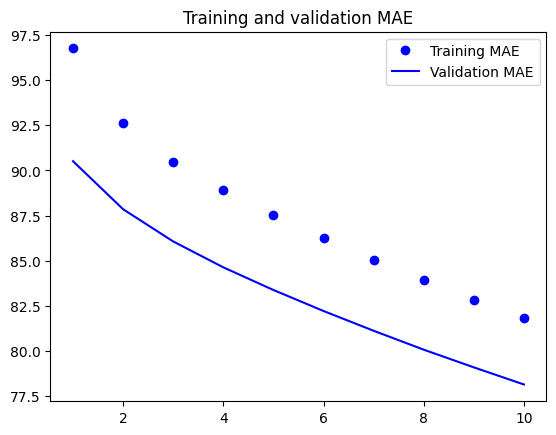

In [18]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("pm25_lstm.keras", save_best_only=True)]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10,
                    validation_data=val_dataset, callbacks=callbacks)
model = keras.models.load_model("pm25_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)
plt.figure()
plt.plot(epochs, mae, 'bo', label='Training MAE')
plt.plot(epochs, val_mae, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

Usei sampling_rate=1 porque os dados já são horários, sequence_length=120 para considerar 5 dias de histórico, delay=sequence_length+24-1 para prever o PM2.5 de 24 horas à frente, e batch_size=256 seguindo o padrão da aula.